# llama3.1:8b — evaluation

Text-block classification into five classes, evaluated against a manually annotated
reference set of 10 Data Management Plans. PDF text extracted with pdfplumber.


In [1]:
import os
from pathlib import Path

if Path.cwd().name == 'notebooks':
    os.chdir(Path.cwd().parent)

import numpy as np
import matplotlib.pyplot as plt

from dmpbridge.evaluation.evaluate import (
    load_method as load_method_old, micro_prf1, compute_f1_rows, LABELS,
)

MODEL, TAG = 'llama3.1:8b', 'llama3.1-8b_pdfplumber_whole_doc'

# Reference categorical palette, slots 1-3 — the set validated for all pairs.
# One hue per metric, used consistently in both charts.
PRECISION, RECALL, F1 = '#2a78d6', '#eb6834', '#1baf7a'
INK, MUTED, SURFACE, GRID = '#0b0b0b', '#52514e', '#fcfcfb', '#e6e6e2'

plt.rcParams.update({
    'figure.facecolor': SURFACE, 'axes.facecolor': SURFACE,
    'text.color': INK, 'axes.labelcolor': MUTED,
    'xtick.color': MUTED, 'ytick.color': MUTED,
    'axes.edgecolor': '#d8d8d4', 'axes.titlecolor': INK,
    'font.size': 10, 'axes.titlesize': 11.5, 'axes.titleweight': 'bold',
    'axes.grid': False, 'legend.frameon': False,
})

df, conf, errors = load_method_old(TAG, exclude=[])
print(f'{MODEL}: {len(df)} documents')


llama3.1:8b: 10 documents


## 1. Metrics

Each predicted block is matched to a reference block by token overlap, giving three
possible outcomes:

| | |
|---|---|
| **TP** &nbsp;true positive | matched to a reference block, with the same class |
| **FP** &nbsp;false positive | predicted with the wrong class, or with no reference counterpart |
| **FN** &nbsp;false negative | a reference block not matched, or matched with the wrong class |

```
precision  =  TP / (TP + FP)
recall     =  TP / (TP + FN)
f1-score   =  2 * precision * recall / (precision + recall)
```

Precision falls when the model over-generates; recall falls when it under-generates.
The f1-score is their harmonic mean, so it stays low unless both are high.

A **confusion matrix** cross-tabulates the true class against the predicted class: the
diagonal counts agreements, and off-diagonal cells identify which classes are being
substituted for which. It is reported in section 3.

Scores below are **micro-averaged** — computed over the pooled counts, so every block
contributes equally regardless of how common its class is.


llama3.1:8b — micro-averaged over 10 documents

  TP    96
  FP    82
  FN    36

  precision  0.539
  recall     0.727
  f1-score   0.619


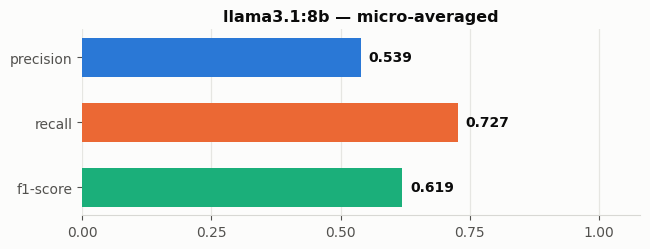

In [2]:
m = micro_prf1(conf)

print(f'{MODEL} — micro-averaged over 10 documents')
print()
print(f"  TP  {m['tp']:>4}")
print(f"  FP  {m['fp']:>4}")
print(f"  FN  {m['fn']:>4}")
print()
print(f"  precision  {m['precision']:.3f}")
print(f"  recall     {m['recall']:.3f}")
print(f"  f1-score   {m['f1']:.3f}")

fig, ax = plt.subplots(figsize=(6.6, 2.6))
names = ['precision', 'recall', 'f1-score']
vals = [m['precision'], m['recall'], m['f1']]
bars = ax.barh(names, vals, color=[PRECISION, RECALL, F1], height=0.6)
for b, v in zip(bars, vals):
    ax.text(v + 0.015, b.get_y() + b.get_height() / 2, f'{v:.3f}',
            va='center', fontweight='bold', color=INK, fontsize=10)
ax.set_xlim(0, 1.08)
ax.set_xticks([0, 0.25, 0.5, 0.75, 1.0])
ax.grid(axis='x', color=GRID, linewidth=0.9)
ax.set_axisbelow(True)
ax.invert_yaxis()
ax.set_title(f'{MODEL} — micro-averaged')
for side in ('top', 'right', 'left'):
    ax.spines[side].set_visible(False)
plt.tight_layout()
plt.show()


## 2. Classification report

Precision, recall and f1-score per class, with support — the number of reference
blocks of that class. Reported in the conventional layout.


In [3]:
per_class = compute_f1_rows(conf).set_index('label')

print(f"{'':<22}{'precision':>10}{'recall':>9}{'f1-score':>10}{'support':>9}")
print()
for lab, r in per_class.iterrows():
    print(f"{lab:<22}{r['precision']:>10.3f}{r['recall']:>9.3f}"
          f"{r['f1']:>10.3f}{int(r['support']):>9}")
print()
print(f"{'micro avg':<22}{m['precision']:>10.3f}{m['recall']:>9.3f}"
      f"{m['f1']:>10.3f}{int(per_class['support'].sum()):>9}")
print(f"{'macro avg':<22}{per_class['precision'].mean():>10.3f}"
      f"{per_class['recall'].mean():>9.3f}{per_class['f1'].mean():>10.3f}"
      f"{int(per_class['support'].sum()):>9}")
w = per_class['support'] / per_class['support'].sum()
print(f"{'weighted avg':<22}{(per_class['precision'] * w).sum():>10.3f}"
      f"{(per_class['recall'] * w).sum():>9.3f}{(per_class['f1'] * w).sum():>10.3f}"
      f"{int(per_class['support'].sum()):>9}")


                       precision   recall  f1-score  support

title                      0.900    0.900     0.900       10
section.title              0.593    0.814     0.686       43
section.description        0.750    0.750     0.750        8
question.text              0.031    0.062     0.042       16
answer.text                0.652    0.818     0.726       55

micro avg                  0.539    0.727     0.619      132
macro avg                  0.585    0.669     0.621      132
weighted avg               0.582    0.727     0.645      132


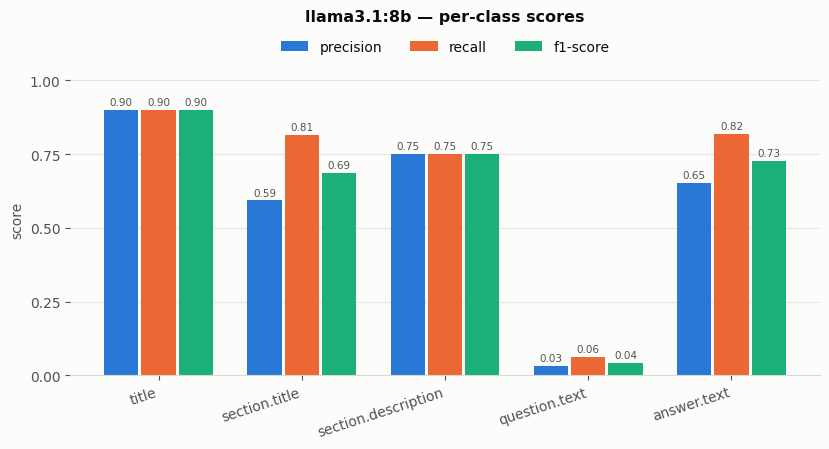

In [4]:
fig, ax = plt.subplots(figsize=(8.4, 4.6))
x = np.arange(len(per_class))
w = 0.26

for k, (col, colour) in enumerate((('precision', PRECISION),
                                   ('recall', RECALL),
                                   ('f1', F1))):
    bars = ax.bar(x + (k - 1) * w, per_class[col], width=w - 0.02,
                  color=colour, label=col if col != 'f1' else 'f1-score')
    # Values sit above the bars: 15 bars are too many to read off the axis,
    # and the axis is what the eye uses for comparison instead.
    ax.bar_label(bars, fmt='%.2f', padding=2, fontsize=7.5, color=MUTED)

ax.set_xticks(x)
ax.set_xticklabels(per_class.index, rotation=18, ha='right')
ax.set_ylim(0, 1.06)
ax.set_yticks([0, 0.25, 0.5, 0.75, 1.0])
ax.set_ylabel('score')
ax.legend(ncol=3, loc='lower center', bbox_to_anchor=(0.5, 1.01),
          borderaxespad=0)
ax.set_title(f'{MODEL} — per-class scores', pad=30)
ax.grid(axis='y', color=GRID, linewidth=0.9)
ax.set_axisbelow(True)
for side in ('top', 'right', 'left'):
    ax.spines[side].set_visible(False)
plt.tight_layout()
plt.show()


## 3. Confusion matrix

Rows are the true class, columns the predicted class. Each cell counts reference blocks
of one class that were predicted as another; the diagonal counts correct classifications.

**How to read it**

- **Read across a row** to see what became of one true class. The row total is that
  class's support, and the diagonal cell divided by the row total is its **recall**.
- **Read down a column** to see everything the model gave one label to. The diagonal
  cell divided by the column total is that class's **precision**.
- **The outlined diagonal is agreement.** Everything off it is an error, and *where* it
  sits names the error: a count at row `question.text`, column `section.title` means
  real questions were labelled as headings.
- **A pair of mirrored off-diagonal cells** means two classes are being swapped for one
  another — usually a definition the prompt has not separated cleanly.

Blocks with no counterpart on either side cannot appear in the matrix — a prediction
with no matching reference block has no true class, and a reference block the model
did not produce has no predicted class. Those are counted separately beneath the plot,
and they are the reason a row may not sum to that class's full support.


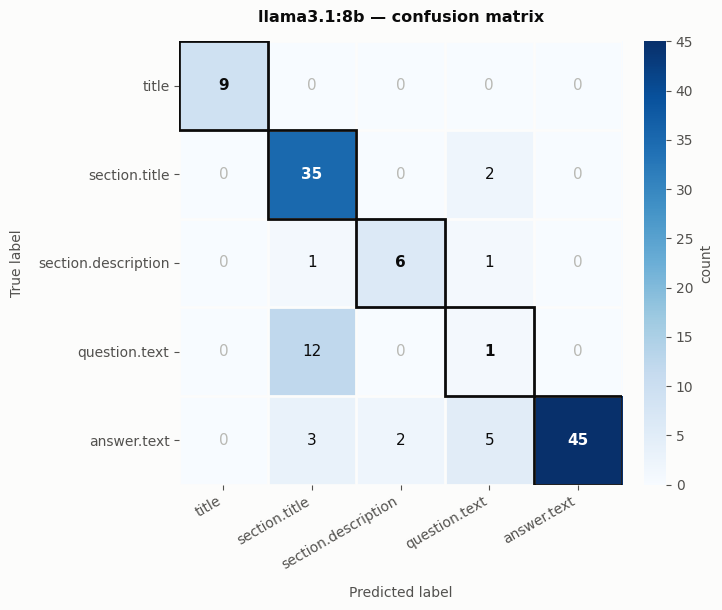

Not representable in the matrix:
  predictions with no matching reference block     56   (count as FP)
  reference blocks with no matching prediction     10   (count as FN)

Largest off-diagonal cells:
    12   true question.text predicted as section.title
     5   true answer.text predicted as question.text
     3   true answer.text predicted as section.title
     2   true section.title predicted as question.text
     2   true answer.text predicted as section.description


In [5]:
cm = np.zeros((len(LABELS), len(LABELS)), dtype=int)
for i, true in enumerate(LABELS):
    for j, pred in enumerate(LABELS):
        cm[i, j] = conf.get(true, {}).get(pred, 0)

fig, ax = plt.subplots(figsize=(7.4, 6.2))
im = ax.imshow(cm, cmap='Blues', vmin=0, vmax=cm.max())
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='count')
cbar.outline.set_visible(False)

thresh = cm.max() * 0.55
for i in range(len(LABELS)):
    for j in range(len(LABELS)):
        v = cm[i, j]
        # Zeros are held back so the counts that matter carry the eye.
        ax.text(j, i, v, ha='center', va='center', fontsize=11,
                fontweight='bold' if i == j else 'normal',
                color='#b9b9b4' if v == 0 else ('white' if v > thresh else INK))

ax.set_xticks(range(len(LABELS)))
ax.set_xticklabels(LABELS, rotation=30, ha='right')
ax.set_yticks(range(len(LABELS)))
ax.set_yticklabels(LABELS)
ax.set_xlabel('Predicted label', labelpad=10)
ax.set_ylabel('True label', labelpad=10)
ax.set_title(f'{MODEL} — confusion matrix', pad=14)

# A 2px surface gap between cells, so adjacent counts read as separate marks.
ax.set_xticks(np.arange(-.5, len(LABELS), 1), minor=True)
ax.set_yticks(np.arange(-.5, len(LABELS), 1), minor=True)
ax.grid(which='minor', color=SURFACE, linewidth=2)
ax.tick_params(which='minor', length=0)

# Outline the diagonal so agreement is findable without reading colour.
# Drawn after the grid, or the grid paints over the edges.
for k in range(len(LABELS)):
    ax.add_patch(plt.Rectangle((k - .5, k - .5), 1, 1, fill=False,
                               edgecolor=INK, linewidth=2.0, zorder=5))
for spine in ax.spines.values():
    spine.set_visible(False)
plt.tight_layout()
plt.show()

unmatched_pred = sum(conf.get('__no_gold__', {}).values())
unmatched_true = sum(conf.get(l, {}).get('__missed__', 0) for l in LABELS)
print('Not representable in the matrix:')
print(f'  predictions with no matching reference block   {unmatched_pred:>4}   (count as FP)')
print(f'  reference blocks with no matching prediction   {unmatched_true:>4}   (count as FN)')

swaps = sorted(((cm[i, j], LABELS[i], LABELS[j])
                for i in range(len(LABELS)) for j in range(len(LABELS))
                if i != j and cm[i, j]), reverse=True)
print()
print('Largest off-diagonal cells:')
for count, true, pred in swaps[:5]:
    print(f'  {count:>4}   true {true} predicted as {pred}')
